# Step 6 - Analysis (Single + Compare)


**How this notebook is organized**

1. Select a cell/tune and resolve run(s).
2. Output plots (single or compare).
3. Input plots (single or compare).
4. Synapse plots (planned).
5. Extra analysis (tables + special cases).

Analysis logic lives in `modules_local/analysis.py`, and plotting in `modules_local/plotting.py`.


## 1. Select runs


In [1]:
# --------------------------
# Defaults (manual mode)
# --------------------------
cell_name = "PV"      # SST, SST_0, PV, PN

tunes_dir = "tunes"
model_dir = "seg_tuned"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison
compare_a_path = ""
compare_b_path = ""

In [2]:
# --------------------------
# Global toggles
# --------------------------
save_plots = False
save_analysis = False
plots_dpi = 150

load_cell_for_analysis = True

# --------------------------
# Output plot options
# --------------------------
plot_outputs = True
plot_output_curve = False
output_curve_mode = "raw"  # raw, normalized
output_norm_mode = "avg"   # avg, peak
output_baseline_ms = 100.0
output_baseline_mode = "point"  # point, window
output_norm_window = "stim"  # stim, full
output_bin_ms = 5.0
output_smooth_ms = 25.0
output_smooth_mode = "causal"  # causal, center
output_scatter_enabled = False
output_scatter_path = ""
output_scatter_time_unit = "s"
output_scatter_label = "Bio scatter"
output_scatter_color = "0.4"
output_scatter_shift_ms = None

plot_spike_stats = False
plot_raster = False
raster_style = "dot"  # "dot" or "line"
plot_window = (None, None)
win_size = 25

multi_plot_type = "line"  # "line", "hist", "both"
multi_shade_mode = None   # None, "sem", "std"
multi_norm_fr = None      # e.g. -4 to normalize to baseline
compare_output_layout = "side-by-side"  # "side-by-side", "stacked", "overlay"

multi_use_bio_curve = False
bio_curve_path = ""
bio_curve_time_col = "Time"
bio_curve_rate_col = "AvgFiringRate"
bio_curve_time_unit = "s"
bio_curve_t_min = 0.0
bio_curve_delay_ms = 0.0
bio_curve_shift_ms = None

# --------------------------
# Auto-run (optional)
# --------------------------
auto_run_outputs = True
auto_run_inputs = True
auto_run_extras = False

# --------------------------
# Input plot options
# --------------------------
plot_inputs_mean = True
plot_input_raster = False
show_input_std = False
input_groups = None
input_bin_ms = None
input_smooth_ms = 25.0
input_raster_trial_idx = 0
input_raster_max_trains = 200
input_raster_win_size = 25.0
input_raster_style = "dot"
input_plot_window = (None, None)

compare_input_layout = "side-by-side"  # "side-by-side" or "stacked"
compare_show_input_std = False

# --------------------------
# Extra analysis toggles
# --------------------------
extra_output_metrics = True
output_peak_window_ms = 100.0
output_drop_window_ms = 100.0
output_auc_window = "stim"  # stim, full

extra_cell_tables = True
extra_geometry_tables = True
extra_synapse_tables = True

extra_compare_cell_tables = False
extra_compare_geometry_tables = False
extra_compare_synapse_tables = True
extra_compare_diff_only = True

extra_snapshot_tables = False
extra_snapshot_diff_only = True
save_snapshot_compare_table = False
snapshot_compare_scope = "full"  # "snapshot", "meta", or "full"
snapshot_compare_format = "csv"  # "csv", "xlsx", or "both"
snapshot_compare_max_depth = 60
snapshot_compare_max_list_items = 200

extra_synapse_weight_plot = False
extra_synapse_distance_plot = False
extra_synapse_groups = None
extra_synapse_weight_bin = 0.1
extra_synapse_distance_bin = 25.0
extra_synapse_density = True


In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = None
    Markdown = None

from modules_local import run_sim, plotting, analysis, analysis_ui

BASE_DIR = analysis.find_scp_root(Path.cwd()).resolve()
CELLS_DIR = BASE_DIR / "cells"

# --------------------------
# Widgets (optional)
# --------------------------
use_widgets = True
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


def _show_md(text: str):
    if display is not None and Markdown is not None:
        display(Markdown(text))
    else:
        print(text)


def _get_selection():
    if use_widgets and _HAVE_WIDGETS and cell_dd is not None:
        cell = cell_dd.value
        tunes = tunes_dd.value
        model = model_dd.value
        run_single = run_single_dd.value
        run_a = run_a_dd.value
        run_b = run_b_dd.value
        comp_a_widget = globals().get("compare_a_path_txt")
        comp_b_widget = globals().get("compare_b_path_txt")
        comp_a = comp_a_widget.value if comp_a_widget is not None else ""
        comp_b = comp_b_widget.value if comp_b_widget is not None else ""
    else:
        cell = cell_name
        tunes = tunes_dir
        model = model_dir
        run_single = run_single_stem
        run_a = run_compare_a
        run_b = run_compare_b
        comp_a = compare_a_path
        comp_b = compare_b_path
    base_dir = CELLS_DIR / cell / tunes / model / "output_data"
    return {
        "cell": cell,
        "tunes": tunes,
        "model": model,
        "base": base_dir,
        "run_single": run_single,
        "run_a": run_a,
        "run_b": run_b,
        "run_a_path": comp_a,
        "run_b_path": comp_b,
    }



def _resolve_single():
    sel = _get_selection()
    run_dir = analysis.resolve_run(sel["base"], sel["run_single"])
    res = run_sim.load_results(run_dir)
    return sel, run_dir, res


def _resolve_compare():
    sel = _get_selection()
    run_a, run_b, res_a, res_b = analysis_ui.resolve_compare(sel)
    return sel, run_a, run_b, res_a, res_b





def _save_fig(fig, out_path: Path):
    analysis.save_figure(fig, out_path, enabled=save_plots, dpi=plots_dpi)


def _save_json(data: dict, out_path: Path):
    analysis.save_json(data, out_path, enabled=save_analysis)


def _format_kv_table(data: dict, *, title: str = "Output metrics") -> str:
    lines = [f"### {title}", "| Metric | Value |", "| --- | --- |"]
    for key, val in data.items():
        lines.append(f"| {key} | {val} |")
    return "\n".join(lines)


def _stim_window(sim_cfg: dict):
    stim_start = sim_cfg.get("stim_start_ms")
    stim_stop = sim_cfg.get("stim_stop_ms")
    stim_dur = sim_cfg.get("stim_duration_ms")
    if stim_stop is None and stim_start is not None and stim_dur is not None:
        stim_stop = float(stim_start) + float(stim_dur)
    return stim_start, stim_stop




def _output_opts():
    return {
        "plot_outputs": plot_outputs,
        "plot_output_curve": plot_output_curve,
        "plot_spike_stats": plot_spike_stats,
        "plot_raster": plot_raster,
        "raster_style": raster_style,
        "plot_window": plot_window,
        "compare_output_layout": compare_output_layout,
        "win_size": win_size,
        "multi_plot_type": multi_plot_type,
        "multi_shade_mode": multi_shade_mode,
        "multi_norm_fr": multi_norm_fr,
        "multi_use_bio_curve": multi_use_bio_curve,
        "bio_curve_path": bio_curve_path,
        "bio_curve_time_col": bio_curve_time_col,
        "bio_curve_rate_col": bio_curve_rate_col,
        "bio_curve_time_unit": bio_curve_time_unit,
        "bio_curve_t_min": bio_curve_t_min,
        "bio_curve_delay_ms": bio_curve_delay_ms,
        "bio_curve_shift_ms": bio_curve_shift_ms,
        "output_curve_mode": output_curve_mode,
        "output_norm_mode": output_norm_mode,
        "output_baseline_ms": output_baseline_ms,
        "output_baseline_mode": output_baseline_mode,
        "output_norm_window": output_norm_window,
        "output_bin_ms": output_bin_ms,
        "output_smooth_ms": output_smooth_ms,
        "output_smooth_mode": output_smooth_mode,
        "output_scatter_enabled": output_scatter_enabled,
        "output_scatter_path": output_scatter_path,
        "output_scatter_time_unit": output_scatter_time_unit,
        "output_scatter_label": output_scatter_label,
        "output_scatter_color": output_scatter_color,
        "output_scatter_shift_ms": output_scatter_shift_ms,
    }


def _input_opts():
    return {
        "plot_inputs_mean": plot_inputs_mean,
        "plot_input_raster": plot_input_raster,
        "show_input_std": show_input_std,
        "input_groups": input_groups,
        "input_bin_ms": input_bin_ms,
        "input_smooth_ms": input_smooth_ms,
        "input_raster_trial_idx": input_raster_trial_idx,
        "input_raster_max_trains": input_raster_max_trains,
        "input_raster_win_size": input_raster_win_size,
        "input_raster_style": input_raster_style,
        "input_plot_window": input_plot_window,
        "compare_input_layout": compare_input_layout,
        "compare_show_input_std": compare_show_input_std,
    }


def run_output_plots():
    sel = _get_selection()
    analysis_ui.run_output_plots(
        sel,
        _output_opts(),
        save_plots=save_plots,
        save_analysis=save_analysis,
        plots_dpi=plots_dpi,
    )


def run_input_plots():
    sel = _get_selection()
    analysis_ui.run_input_plots(
        sel,
        _input_opts(),
        save_plots=save_plots,
        save_analysis=save_analysis,
        plots_dpi=plots_dpi,
    )


def run_output_metrics():
    if not extra_output_metrics:
        print("Output metrics disabled (set extra_output_metrics=True).")
        return
    sel = _get_selection()
    metrics = analysis_ui.run_output_metrics(
        sel,
        {
            **_output_opts(),
            "output_peak_window_ms": output_peak_window_ms,
            "output_drop_window_ms": output_drop_window_ms,
            "output_auc_window": output_auc_window,
        },
        save_analysis=save_analysis,
    )
    if metrics:
        _show_md(_format_kv_table(metrics, title=f"Output metrics ({analysis.run_label(analysis.resolve_run(sel['base'], sel['run_single']))})"))
def run_extra_tables():
    sel, run_dir, res = _resolve_single()
    if not load_cell_for_analysis:
        print("Cell loading disabled; enable load_cell_for_analysis to run this section.")
        return

    tune_dir = (CELLS_DIR / sel["cell"] / sel["tunes"] / sel["model"]).resolve()
    try:
        cell, geom, geom_cfg = analysis.load_cell_and_geometry(tune_dir)
    except Exception as exc:
        print("Cell/geometry load failed:", exc)
        return

    if extra_cell_tables:
        cell_sections = analysis.summarize_cell_sections(cell)
        mech_summary = analysis.summarize_mechanisms(cell)
        _show_md(analysis.format_section_summary_table(cell_sections, title=f"{analysis.run_label(run_dir)} cell sections"))
        _show_md(analysis.format_mechanism_summary_table(mech_summary, title="Mechanisms (per section group)"))
        _save_json(cell_sections, analysis.analysis_dir_for_run(run_dir) / "cell_sections.json")
        _save_json(mech_summary, analysis.analysis_dir_for_run(run_dir) / "cell_mechanisms.json")

    if extra_geometry_tables:
        geom_summary = analysis.summarize_geometry(geom, geom_config=geom_cfg)
        _show_md(analysis.format_geometry_summary_table(geom_summary, title="Geometry distances"))
        _save_json(geom_summary, analysis.analysis_dir_for_run(run_dir) / "geometry_summary.json")

    if extra_synapse_tables:
        syn_summary = analysis.summarize_synapse_records(
            res.get("syn_records") or {},
            geom=geom,
            duration_ms=analysis._get_duration_ms(res),
        )
        if syn_summary.get("groups"):
            _show_md(analysis.format_synapse_summary_table(syn_summary, title="Synapse placement + weights"))
            _save_json(syn_summary, analysis.analysis_dir_for_run(run_dir) / "synapse_summary.json")
        else:
            print("No synapse records found for this run.")


def run_extra_compare():
    sel, run_a, run_b, res_a, res_b = _resolve_compare()
    if run_b is None:
        print("Comparison disabled (set Compare B to a run name).")
        return

    label_a = analysis.run_label(run_a)
    label_b = analysis.run_label(run_b)
    tune_dir = (CELLS_DIR / sel["cell"] / sel["tunes"] / sel["model"]).resolve()

    cell = None
    geom = None
    geom_cfg = None
    if load_cell_for_analysis and (extra_compare_cell_tables or extra_compare_geometry_tables or extra_compare_synapse_tables):
        try:
            cell, geom, geom_cfg = analysis.load_cell_and_geometry(tune_dir)
        except Exception as exc:
            print("Cell/geometry load failed:", exc)

    if extra_compare_cell_tables and cell is not None:
        cell_sections = analysis.summarize_cell_sections(cell)
        mech_summary = analysis.summarize_mechanisms(cell)
        _show_md(
            analysis.format_section_summary_compare(
                cell_sections,
                cell_sections,
                labels=(label_a, label_b),
                diff_only=extra_compare_diff_only,
                title="Cell sections",
            )
        )
        _show_md(
            analysis.format_mechanism_summary_compare(
                mech_summary,
                mech_summary,
                labels=(label_a, label_b),
                diff_only=extra_compare_diff_only,
                title="Mechanisms",
            )
        )

    if extra_compare_geometry_tables and geom is not None:
        geom_summary = analysis.summarize_geometry(geom, geom_config=geom_cfg)
        _show_md(
            analysis.format_geometry_summary_compare(
                geom_summary,
                geom_summary,
                labels=(label_a, label_b),
                diff_only=extra_compare_diff_only,
                title="Geometry distances",
            )
        )

    syn_summary_a = analysis.summarize_synapse_records(
        res_a.get("syn_records") or {},
        geom=geom,
        duration_ms=analysis._get_duration_ms(res_a),
    )
    syn_summary_b = analysis.summarize_synapse_records(
        res_b.get("syn_records") or {},
        geom=geom,
        duration_ms=analysis._get_duration_ms(res_b),
    )

    if extra_compare_synapse_tables and (syn_summary_a.get("groups") or syn_summary_b.get("groups")):
        _show_md(
            analysis.format_synapse_summary_compare(
                syn_summary_a,
                syn_summary_b,
                labels=(label_a, label_b),
                diff_only=extra_compare_diff_only,
                title="Synapse summary",
            )
        )

    if extra_synapse_weight_plot or extra_synapse_distance_plot:
        syn_groups = extra_synapse_groups
        vals_w_a = analysis.extract_synapse_values(res_a.get("syn_records") or {}, "weight", syn_groups)
        vals_w_b = analysis.extract_synapse_values(res_b.get("syn_records") or {}, "weight", syn_groups)
        vals_d_a = analysis.extract_synapse_values(res_a.get("syn_records") or {}, "distance", syn_groups)
        vals_d_b = analysis.extract_synapse_values(res_b.get("syn_records") or {}, "distance", syn_groups)

        if extra_synapse_weight_plot:
            fig_w = plotting.plot_synapse_compare_hist(
                vals_w_a,
                vals_w_b,
                labels=(label_a, label_b),
                bin_width=extra_synapse_weight_bin,
                xlabel="Synaptic weight",
                title="Synapse weight distribution",
                density=extra_synapse_density,
            )
            if fig_w is not None:
                _save_fig(fig_w, analysis.plot_dir_for_compare(sel["base"], run_a, run_b) / "syn_weight_compare.png")

        if extra_synapse_distance_plot:
            fig_d = plotting.plot_synapse_compare_hist(
                vals_d_a,
                vals_d_b,
                labels=(label_a, label_b),
                bin_width=extra_synapse_distance_bin,
                xlabel="Distance from soma (um)",
                title="Synapse distance distribution",
                density=extra_synapse_density,
            )
            if fig_d is not None:
                _save_fig(fig_d, analysis.plot_dir_for_compare(sel["base"], run_a, run_b) / "syn_distance_compare.png")


def run_snapshot_compare():
    if not extra_snapshot_tables:
        print("Snapshot compare disabled (set extra_snapshot_tables=True).")
        return
    sel, run_a, run_b, res_a, res_b = _resolve_compare()
    if run_b is None:
        print("Snapshot compare disabled (set Compare B to a run name).")
        return

    label_a = analysis.run_label(run_a)
    label_b = analysis.run_label(run_b)
    out_dir = analysis.analysis_dir_for_compare(sel["base"], run_a, run_b)

    report = analysis.snapshot_compare_report(
        run_a,
        run_b,
        labels=(label_a, label_b),
        max_diffs=200,
        diff_only=extra_snapshot_diff_only,
        save_table=save_snapshot_compare_table,
        table_scope=snapshot_compare_scope,
        table_format=snapshot_compare_format,
        table_max_depth=snapshot_compare_max_depth,
        table_max_list_items=snapshot_compare_max_list_items,
        out_dir=out_dir,
        save_report_json=save_analysis,
    )

    _show_md(report.get("snapshot_diff_table") or "")
    if not extra_snapshot_diff_only:
        _show_md(
            analysis.format_snapshot_compare(
                report["report"]["snapshot_a"],
                report["report"]["snapshot_b"],
                labels=(label_a, label_b),
            )
        )
    _show_md(report.get("manifest_diff_table") or "")
    _show_md(report.get("deep_diff_table") or "")


def run_iclamp_analysis():
    sel, run_dir, res = _resolve_single()
    mode = res.get("mode")
    if mode != "iclamp":
        print(f"IClamp analysis skipped (mode={mode!r}). Select an iclamp run and re-run this cell.")
        return

    stats = analysis.summarize_iclamp(res)
    if stats is None:
        print("No trace data found for IClamp run.")
        return

    print(f"Baseline Vm: {stats['baseline']:.2f} mV")
    print(f"Peak Vm: {stats['peak']:.2f} mV, Min Vm: {stats['vmin']:.2f} mV")
    if stats['spike_count'] is not None:
        print(f"Spike count during pulse: {stats['spike_count']} (rate {stats['spike_rate']:.2f} Hz)")

    plt.figure(figsize=(6, 4))
    plt.plot(stats['T'], stats['V'], lw=1.5)
    if stats['delay_ms'] is not None:
        plt.axvline(float(stats['delay_ms']), color='k', ls='--', lw=1)
    if stats['delay_ms'] is not None and stats['dur_ms'] is not None:
        plt.axvline(float(stats['delay_ms'] + stats['dur_ms']), color='k', ls='--', lw=1)
    plt.xlabel("Time (ms)")
    plt.ylabel("Vm (mV)")
    plt.title("IClamp Vm trace")
    plt.tight_layout()

    iclamp_payload = res.get("iclamp", {}) or {}
    currents = iclamp_payload.get("I")
    if isinstance(currents, dict) and currents:
        total_I = None
        for arr in currents.values():
            if total_I is None:
                total_I = arr.copy()
            else:
                total_I = total_I + arr
        if total_I is not None:
            plt.figure(figsize=(6, 3))
            plt.plot(stats['T'], total_I, lw=1.0)
            plt.xlabel("Time (ms)")
            plt.ylabel("Total membrane current")
            plt.title("Summed currents (if recorded)")
            plt.tight_layout()

    sel_local = _get_selection()
    if sel_local.get("run_b") not in (None, "none", "None"):
        try:
            run_a = analysis.resolve_run(sel_local["base"], sel_local.get("run_a"))
            run_b = analysis.resolve_run(sel_local["base"], sel_local.get("run_b"))
            res_a = run_sim.load_results(run_a)
            res_b = run_sim.load_results(run_b)
        except Exception as exc:
            print(f"IClamp compare failed to load runs: {exc}")
        else:
            if res_a.get("mode") != "iclamp" or res_b.get("mode") != "iclamp":
                print("IClamp compare skipped: both runs must be mode='iclamp'.")
            else:
                stats_a = analysis.summarize_iclamp(res_a)
                stats_b = analysis.summarize_iclamp(res_b)
                if stats_a is None or stats_b is None:
                    print("IClamp compare skipped: missing traces.")
                else:
                    label_a = analysis.run_label(run_a)
                    label_b = analysis.run_label(run_b)
                    print(f"Compare A: {label_a}")
                    print(f"  Baseline {stats_a['baseline']:.2f} mV, Peak {stats_a['peak']:.2f} mV, Min {stats_a['vmin']:.2f} mV")
                    if stats_a['spike_count'] is not None:
                        print(f"  Spikes {stats_a['spike_count']} (rate {stats_a['spike_rate']:.2f} Hz)")
                    print(f"Compare B: {label_b}")
                    print(f"  Baseline {stats_b['baseline']:.2f} mV, Peak {stats_b['peak']:.2f} mV, Min {stats_b['vmin']:.2f} mV")
                    if stats_b['spike_count'] is not None:
                        print(f"  Spikes {stats_b['spike_count']} (rate {stats_b['spike_rate']:.2f} Hz)")

                    plt.figure(figsize=(6, 4))
                    plt.plot(stats_a['T'], stats_a['V'], lw=1.5, label=label_a)
                    plt.plot(stats_b['T'], stats_b['V'], lw=1.5, label=label_b)
                    plt.xlabel("Time (ms)")
                    plt.ylabel("Vm (mV)")
                    plt.title("IClamp compare (Vm)")
                    plt.legend()
                    plt.tight_layout()


# --------------------------
# Shared selection widgets
# --------------------------
cell_dd = None
run_single_dd = None
run_a_dd = None
run_b_dd = None
save_plots_cb = None
save_analysis_cb = None


def _sync_common():
    global save_plots, save_analysis
    if save_plots_cb is not None:
        save_plots = bool(save_plots_cb.value)
    if save_analysis_cb is not None:
        save_analysis = bool(save_analysis_cb.value)


if use_widgets and _HAVE_WIDGETS:
    cells = analysis.list_cells(BASE_DIR) or [cell_name]
    cell_dd = widgets.Dropdown(options=cells, value=cell_name, description="Cell")

    tunes = analysis.list_tunes(BASE_DIR, cell_dd.value) or [tunes_dir]
    tunes_dd = widgets.Dropdown(options=tunes, value=tunes_dir, description="Tunes")

    models = analysis.list_models(BASE_DIR, cell_dd.value, tunes_dd.value) or [model_dir]
    model_dd = widgets.Dropdown(options=models, value=model_dir, description="Model")

    run_single_dd = widgets.Dropdown(options=["latest", "previous"], value=run_single_stem, description="Single")
    run_a_dd = widgets.Dropdown(options=["latest", "previous"], value=run_compare_a, description="Compare A")
    run_b_dd = widgets.Dropdown(options=["none", "latest", "previous"], value=run_compare_b, description="Compare B")

    compare_a_path_txt = widgets.Text(value=compare_a_path, description="Compare A path")
    compare_b_path_txt = widgets.Text(value=compare_b_path, description="Compare B path")

    def _refresh_runs(*_):
        base_dir = CELLS_DIR / cell_dd.value / tunes_dd.value / model_dd.value / "output_data"
        names = [analysis.run_label(p) for p in analysis.collect_run_candidates(base_dir)]
        options = ["latest", "previous"] + names
        run_single_dd.options = options
        run_a_dd.options = options
        run_b_dd.options = ["none"] + options

    def _refresh_models(*_):
        models = analysis.list_models(BASE_DIR, cell_dd.value, tunes_dd.value) or [model_dir]
        model_dd.options = models
        if model_dd.value not in model_dd.options:
            model_dd.value = model_dd.options[0]
        _refresh_runs()

    cell_dd.observe(_refresh_models, names="value")
    tunes_dd.observe(_refresh_models, names="value")
    model_dd.observe(_refresh_runs, names="value")

    _refresh_runs()

    save_plots_cb = widgets.Checkbox(value=save_plots, description="Save plots")
    save_analysis_cb = widgets.Checkbox(value=save_analysis, description="Save analysis JSON")

    display(widgets.HBox([cell_dd, tunes_dd, model_dd, run_single_dd]))
    display(widgets.HBox([run_a_dd, run_b_dd, compare_a_path_txt, compare_b_path_txt]))
    display(widgets.HBox([save_plots_cb, save_analysis_cb]))
else:
    print("Widgets not enabled or ipywidgets unavailable.")


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


In [4]:
# (optional) quick selection check
_get_selection()


{'cell': 'PV',
 'tunes': 'tunes',
 'model': 'seg_tuned',
 'base': PosixPath('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data'),
 'run_single': 'latest',
 'run_a': 'latest',
 'run_b': 'none',
 'run_a_path': '',
 'run_b_path': ''}

## 2. Output plots (standard)


In [5]:
# Outputs UI (single or compare)
if use_widgets and _HAVE_WIDGETS:
    out_outputs = widgets.Output()

    outputs_cb = widgets.Checkbox(value=plot_outputs, description="Outputs")
    output_curve_cb = widgets.Checkbox(value=plot_output_curve, description="Output curve")
    spikes_cb = widgets.Checkbox(value=plot_spike_stats, description="Spike stats")

    outputs_raster_cb = widgets.Checkbox(value=plot_raster, description="Output raster")
    outputs_style_dd = widgets.Dropdown(options=["dot", "line"], value=raster_style, description="Raster style")
    outputs_win_txt = widgets.FloatText(value=win_size, description="Win size")
    window_start_txt = widgets.Text(value="" if plot_window[0] is None else str(plot_window[0]), description="tstart")
    window_end_txt = widgets.Text(value="" if plot_window[1] is None else str(plot_window[1]), description="tstop")

    output_curve_mode_dd = widgets.Dropdown(options=["raw", "normalized"], value=output_curve_mode, description="Curve mode")
    output_norm_mode_dd = widgets.Dropdown(options=["avg", "peak"], value=output_norm_mode, description="Norm mode")
    output_baseline_txt = widgets.FloatText(value=output_baseline_ms, description="Baseline ms")
    output_baseline_mode_dd = widgets.Dropdown(options=["point", "window"], value=output_baseline_mode, description="Baseline mode")
    output_norm_window_dd = widgets.Dropdown(options=["stim", "full"], value=output_norm_window, description="Norm window")
    output_bin_txt = widgets.Text(value="" if output_bin_ms is None else str(output_bin_ms), description="Curve bin ms")
    output_smooth_txt = widgets.Text(value="" if output_smooth_ms is None else str(output_smooth_ms), description="Curve smooth ms")
    output_smooth_mode_dd = widgets.Dropdown(options=["causal", "center"], value=output_smooth_mode, description="Curve smooth mode")

    output_scatter_cb = widgets.Checkbox(value=output_scatter_enabled, description="Scatter curve")
    output_scatter_path_txt = widgets.Text(value=output_scatter_path, description="Scatter path")
    output_scatter_unit_dd = widgets.Dropdown(options=["s", "ms"], value=output_scatter_time_unit, description="Scatter unit")
    output_scatter_label_txt = widgets.Text(value=output_scatter_label, description="Scatter label")
    output_scatter_color_txt = widgets.Text(value=output_scatter_color, description="Scatter color")
    output_scatter_shift_txt = widgets.Text(value="" if output_scatter_shift_ms is None else str(output_scatter_shift_ms), description="Scatter shift ms")

    outputs_plot_type_dd = widgets.Dropdown(options=["line", "hist", "both"], value=multi_plot_type, description="Plot type")
    outputs_shade_dd = widgets.Dropdown(options=["none", "sem", "std"], value="none" if multi_shade_mode is None else multi_shade_mode, description="Shade")
    outputs_norm_txt = widgets.Text(value="" if multi_norm_fr is None else str(multi_norm_fr), description="Norm FR")
    outputs_compare_layout_dd = widgets.Dropdown(options=["side-by-side", "stacked", "overlay"], value=compare_output_layout, description="Compare layout")

    outputs_bio_cb = widgets.Checkbox(value=multi_use_bio_curve, description="Bio curve")
    outputs_bio_path_txt = widgets.Text(value=bio_curve_path, description="Bio path")
    outputs_bio_shift_txt = widgets.Text(value="" if bio_curve_shift_ms is None else str(bio_curve_shift_ms), description="Bio shift")

    outputs_btn = widgets.Button(description="Run output plots")

    def _on_outputs(_):
        global plot_outputs, plot_output_curve, plot_spike_stats
        global plot_raster, raster_style, win_size, plot_window
        global output_curve_mode, output_norm_mode, output_baseline_ms, output_norm_window
        global output_baseline_mode
        global output_bin_ms, output_smooth_ms, output_smooth_mode
        global output_scatter_enabled, output_scatter_path, output_scatter_time_unit
        global output_scatter_label, output_scatter_color, output_scatter_shift_ms
        global multi_plot_type, multi_shade_mode, multi_norm_fr
        global compare_output_layout
        global multi_use_bio_curve, bio_curve_path, bio_curve_shift_ms
        _sync_common()
        plot_outputs = outputs_cb.value
        plot_output_curve = output_curve_cb.value
        plot_spike_stats = spikes_cb.value
        plot_raster = outputs_raster_cb.value
        raster_style = outputs_style_dd.value
        win_size = float(outputs_win_txt.value)
        plot_window = (
            analysis.parse_optional_float(window_start_txt.value),
            analysis.parse_optional_float(window_end_txt.value),
        )
        output_curve_mode = output_curve_mode_dd.value
        output_norm_mode = output_norm_mode_dd.value
        output_baseline_ms = float(output_baseline_txt.value)
        output_baseline_mode = output_baseline_mode_dd.value
        output_norm_window = output_norm_window_dd.value
        output_bin_ms = analysis.parse_optional_float(output_bin_txt.value)
        output_smooth_ms = analysis.parse_optional_float(output_smooth_txt.value)
        output_smooth_mode = output_smooth_mode_dd.value
        output_scatter_enabled = output_scatter_cb.value
        output_scatter_path = output_scatter_path_txt.value.strip()
        output_scatter_time_unit = output_scatter_unit_dd.value
        output_scatter_label = output_scatter_label_txt.value.strip()
        output_scatter_color = output_scatter_color_txt.value.strip()
        output_scatter_shift_ms = analysis.parse_optional_float(output_scatter_shift_txt.value)
        multi_plot_type = outputs_plot_type_dd.value
        shade_val = outputs_shade_dd.value
        multi_shade_mode = None if shade_val in ("none", "", None) else shade_val
        multi_norm_fr = analysis.parse_optional_float(outputs_norm_txt.value)
        compare_output_layout = outputs_compare_layout_dd.value
        multi_use_bio_curve = outputs_bio_cb.value
        bio_curve_path = outputs_bio_path_txt.value.strip()
        bio_curve_shift_ms = analysis.parse_optional_float(outputs_bio_shift_txt.value)
        with out_outputs:
            out_outputs.clear_output()
            run_output_plots()

    outputs_btn.on_click(_on_outputs)

    display(
        widgets.VBox([
            widgets.HBox([outputs_btn, outputs_cb, output_curve_cb, spikes_cb]),
            widgets.HBox([outputs_raster_cb, outputs_style_dd, outputs_win_txt]),
            widgets.HBox([window_start_txt, window_end_txt]),
            widgets.HBox([output_curve_mode_dd, output_norm_mode_dd, output_baseline_txt, output_baseline_mode_dd, output_norm_window_dd]),
            widgets.HBox([output_bin_txt, output_smooth_txt, output_smooth_mode_dd]),
            widgets.HBox([output_scatter_cb, output_scatter_path_txt, output_scatter_unit_dd]),
            widgets.HBox([output_scatter_label_txt, output_scatter_color_txt, output_scatter_shift_txt]),
            widgets.HBox([outputs_plot_type_dd, outputs_shade_dd, outputs_norm_txt]),
            widgets.HBox([outputs_compare_layout_dd]),
            widgets.HBox([outputs_bio_cb, outputs_bio_path_txt, outputs_bio_shift_txt]),
            out_outputs,
        ])
    )
else:
    print("Widgets not enabled or ipywidgets unavailable. Run run_output_plots() manually.")



In [ ]:
# Auto-run outputs (UI)
if use_widgets and _HAVE_WIDGETS and a I uto_run_outputs:
    try:
        _on_outputs(None)
    except Exception as exc:
        print(f"Auto-run outputs failed: {exc}")


## 3. Input plots (standard)


In [7]:
# Inputs UI (single or compare)
if use_widgets and _HAVE_WIDGETS:
    out_inputs = widgets.Output()

    inputs_mean_cb = widgets.Checkbox(value=plot_inputs_mean, description="Inputs mean")
    inputs_raster_cb = widgets.Checkbox(value=plot_input_raster, description="Inputs raster")
    inputs_std_cb = widgets.Checkbox(value=show_input_std, description="Show std")

    inputs_groups_txt = widgets.Text(value="" if input_groups is None else ",".join(input_groups), description="Groups")
    inputs_bin_txt = widgets.Text(value="" if input_bin_ms is None else str(input_bin_ms), description="Bin ms")
    inputs_smooth_txt = widgets.Text(value="" if input_smooth_ms is None else str(input_smooth_ms), description="Smooth ms")

    raster_trial_txt = widgets.IntText(value=input_raster_trial_idx, description="Raster trial")
    raster_max_txt = widgets.IntText(value=input_raster_max_trains, description="Max trains")
    raster_win_txt = widgets.FloatText(value=input_raster_win_size, description="Raster win")
    raster_style_dd = widgets.Dropdown(options=["dot", "line"], value=input_raster_style, description="Raster style")

    input_window_start_txt = widgets.Text(value="" if input_plot_window[0] is None else str(input_plot_window[0]), description="tstart")
    input_window_end_txt = widgets.Text(value="" if input_plot_window[1] is None else str(input_plot_window[1]), description="tstop")

    compare_layout_dd = widgets.Dropdown(options=["side-by-side", "stacked", "overlay"], value=compare_input_layout, description="Layout")
    compare_std_cb = widgets.Checkbox(value=compare_show_input_std, description="Compare std")

    inputs_btn = widgets.Button(description="Run input plots")

    def _on_inputs(_):
        global plot_inputs_mean, plot_input_raster, show_input_std
        global input_groups, input_bin_ms, input_smooth_ms
        global input_raster_trial_idx, input_raster_max_trains, input_raster_win_size, input_raster_style
        global input_plot_window, compare_input_layout, compare_show_input_std
        _sync_common()
        plot_inputs_mean = inputs_mean_cb.value
        plot_input_raster = inputs_raster_cb.value
        show_input_std = inputs_std_cb.value
        input_groups = analysis.parse_groups(inputs_groups_txt.value)
        input_bin_ms = analysis.parse_optional_float(inputs_bin_txt.value)
        input_smooth_ms = analysis.parse_optional_float(inputs_smooth_txt.value)
        input_raster_trial_idx = int(raster_trial_txt.value)
        input_raster_max_trains = int(raster_max_txt.value)
        input_raster_win_size = float(raster_win_txt.value)
        input_raster_style = raster_style_dd.value
        input_plot_window = (
            analysis.parse_optional_float(input_window_start_txt.value),
            analysis.parse_optional_float(input_window_end_txt.value),
        )
        compare_input_layout = compare_layout_dd.value
        compare_show_input_std = compare_std_cb.value
        with out_inputs:
            out_inputs.clear_output()
            run_input_plots()

    inputs_btn.on_click(_on_inputs)

    display(
        widgets.VBox([
            widgets.HBox([inputs_btn, inputs_mean_cb, inputs_raster_cb, inputs_std_cb]),
            widgets.HBox([inputs_groups_txt, inputs_bin_txt, inputs_smooth_txt]),
            widgets.HBox([raster_trial_txt, raster_max_txt, raster_win_txt, raster_style_dd]),
            widgets.HBox([input_window_start_txt, input_window_end_txt]),
            widgets.HBox([compare_layout_dd, compare_std_cb]),
            out_inputs,
        ])
    )
else:
    print("Widgets not enabled or ipywidgets unavailable. Run run_input_plots() manually.")


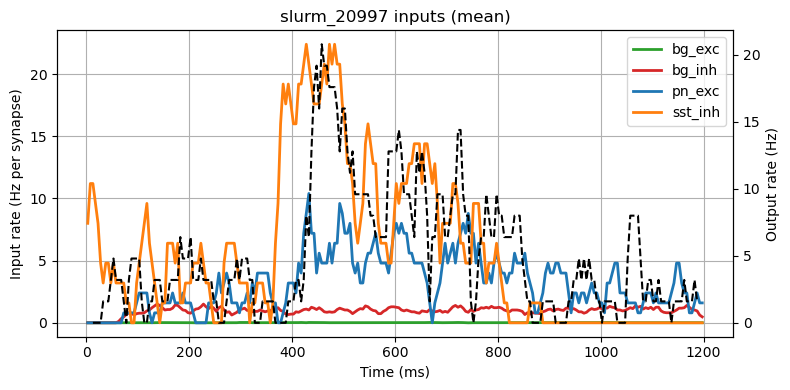

In [8]:
# Auto-run inputs (UI)
if use_widgets and _HAVE_WIDGETS and auto_run_inputs:
    try:
        _on_inputs(None)
    except Exception as exc:
        print(f"Auto-run inputs failed: {exc}")


## 4. Synapse plots (planned)


## 5. Extra analysis (tables + special cases)


In [9]:
# Manual: single-run tables (extra)
run_extra_tables()


NEURON: Ih is not a MECHANISM
 near line 1
 forsec "soma" { insert Ih }
                         ^
NEURON: Nap is not a MECHANISM
 near line 1
 forsec "soma" { insert Nap }
                          ^
NEURON: NaTa is not a MECHANISM
 near line 1
 forsec "soma" { insert NaTa }
                           ^
NEURON: Kd is not a MECHANISM
 near line 1
 forsec "soma" { insert Kd }
                         ^
NEURON: Kv2like is not a MECHANISM
 near line 1
 forsec "soma" { insert Kv2like }
                              ^
NEURON: Kv3_1 is not a MECHANISM
 near line 1
 forsec "soma" { insert Kv3_1 }
                            ^
NEURON: K_T is not a MECHANISM
 near line 1
 forsec "soma" { insert K_T }
                          ^
NEURON: Im_v2 is not a MECHANISM
 near line 1
 forsec "soma" { insert Im_v2 }
                            ^
NEURON: SK is not a MECHANISM
 near line 1
 forsec "soma" { insert SK }
                         ^
NEURON: Ca_HVA is not a MECHANISM
 near line 1
 forsec "soma" { 

Loaded Allen cell for 'PV' from /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/manifest.json, soma_diam_multiplier=6.0, Vinit=-71.0
Geometry defined for 'PV': 1 soma segs, 46 proximal dend segs, 41 distal dend segs, 97 total dend segs.


**slurm_20997 cell sections**
| Group | n_sections | n_segments | total_length_um | mean_diam_um | total_area_um2 |
| --- | --- | --- | --- | --- | --- |
| soma | 1 | 1 | 14.6 | 87.6 | 4018 |
| dend | 41 | 97 | 1957 | 0.3214 | 1976 |
| apic | 0 | 0 | 0 | — | 0 |
| axon | 2 | 2 | 60 | 1 | 188.5 |
| all | 44 | 100 | 2032 | 1.208 | 6182 |

**Mechanisms (per section group)**
| Group | density_mechs | point_mechs | ions |
| --- | --- | --- | --- |
| soma | pas=1 | — | — |
| dend | pas=41 | — | — |
| apic | — | — | — |
| axon | pas=2 | — | — |
| all | pas=44 | — | — |

**Geometry distances**
| Group | n_segments | dist_min_um | dist_mean_um | dist_max_um | dist_std_um |
| --- | --- | --- | --- | --- | --- |
| soma | 1 | 0 | 0 | 0 | 0 |
| proximal | 46 | 22.17 | 61.05 | 97.28 | 21.64 |
| distal | 41 | 101.2 | 144.4 | 213.5 | 27.69 |
| all_dend | 97 | 2.639 | 91.15 | 213.5 | 53.25 |

No synapse records found for this run.


### Output metrics (bio)


In [10]:
run_output_metrics()


### Output metrics (slurm_20997)
| Metric | Value |
| --- | --- |
| peak_window_ms | 100.0 |
| drop_window_ms | 100.0 |
| auc_window | stim |
| stim_start_ms | 400.0 |
| stim_stop_ms | 800.0 |
| peak_time_ms | 467.5 |
| peak_value | 20.800000000000004 |
| peak_latency_ms | 67.5 |
| drop_time_ms | 497.5 |
| drop_value | 16.0 |
| drop_pct | 23.076923076923094 |
| auc | 3836.0 |
| auc_units | Hz*ms |

### 5.1 Comparison tables + synapse compare plots (optional)


In [11]:
# Manual: comparison tables + synapse compare plots (extra)
run_extra_compare()


Comparison disabled (set Compare B to a run name).


### 4.2 Snapshot compare tables (optional)


In [12]:
# Manual: snapshot compare tables (extra)
run_snapshot_compare()


Snapshot compare disabled (set extra_snapshot_tables=True).


### 4.3 IClamp analysis (optional)


In [13]:
# Manual: IClamp analysis (extra)
run_iclamp_analysis()


IClamp analysis skipped (mode='multi'). Select an iclamp run and re-run this cell.


In [14]:
# Auto-run plots with defaults (optional)
if not (use_widgets and _HAVE_WIDGETS):
    if auto_run_outputs:
        try:
            run_output_plots()
        except Exception as exc:
            print(f"Auto-run outputs failed: {exc}")
    if auto_run_inputs:
        try:
            run_input_plots()
        except Exception as exc:
            print(f"Auto-run inputs failed: {exc}")
    if auto_run_extras:
        try:
            run_output_metrics()
        except Exception as exc:
            print(f"Auto-run output metrics failed: {exc}")
